## Data Exploration Notebook


 
 ## Business Context
  - Multiple bars experiencing stockouts and overstocking.
  - Need to forecast demand and optimize inventory levels.
  - Data: Historical inventory movements across different locations.
 
 ## Objectives
 1. Understand data structure and quality.
 2. Identify patterns and trends.
 3. Detect anomalies and data issues.
 4. Formulate initial hypotheses.

# import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


# Load the Data.

In [2]:
# Load data
df = pd.read_excel('../data/Consumption Dataset.xlsx')
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head(5)

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [4]:
df.tail()

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
6570,2024-01-01 21:03:00,Anderson's Bar,Beer,Coors,2.467080e+03,0.00,321.06,2146.02
6571,2024-01-01 21:15:00,Anderson's Bar,Rum,Malibu,8.526513e-14,1743.64,175.05,1568.59
6572,2024-01-01 18:34:00,Anderson's Bar,Whiskey,Jack Daniels,4.192660e+03,0.00,197.60,3995.06
6573,2024-01-01 22:46:00,Thomas's Bar,Vodka,Absolut,2.424950e+03,0.00,128.52,2296.43
6574,2024-01-01 21:26:00,Thomas's Bar,Rum,Bacardi,1.778360e+03,1195.45,572.60,2401.21


In [5]:
# %%
# Basic information
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== DATASET OVERVIEW ===
Shape: (6575, 8)
Columns: ['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name', 'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']
Memory usage: 1.33 MB


In [6]:
# Data types and missing values
print("\n=== DATA TYPES & MISSING VALUES ===")
print(df.info())
print(f"\nMissing values per column:")
print(df.isnull().sum())


=== DATA TYPES & MISSING VALUES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date Time Served      6575 non-null   datetime64[ns]
 1   Bar Name              6575 non-null   object        
 2   Alcohol Type          6575 non-null   object        
 3   Brand Name            6575 non-null   object        
 4   Opening Balance (ml)  6575 non-null   float64       
 5   Purchase (ml)         6575 non-null   float64       
 6   Consumed (ml)         6575 non-null   float64       
 7   Closing Balance (ml)  6575 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 411.1+ KB
None

Missing values per column:
Date Time Served        0
Bar Name                0
Alcohol Type            0
Brand Name              0
Opening Balance (ml)    0
Purchase (ml)           0
Consumed (ml)  

In [7]:
# Basic statistics for numerical columns
print("\n=== BASIC STATISTICS ===")
numeric_cols = ['Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']
print(df[numeric_cols].describe())



=== BASIC STATISTICS ===
       Opening Balance (ml)  Purchase (ml)  Consumed (ml)  \
count           6575.000000    6575.000000    6575.000000   
mean            2468.393518     315.841757     299.419264   
std             2284.556232     582.120264     191.903874   
min                0.000000       0.000000       0.000000   
25%              619.135000       0.000000     156.640000   
50%             1848.440000       0.000000     300.390000   
75%             3853.020000     526.345000     450.870000   
max            11862.520000    1999.840000    1180.580000   

       Closing Balance (ml)  
count           6575.000000  
mean            2484.816011  
std             2302.362117  
min                0.000000  
25%              611.000000  
50%             1849.840000  
75%             3906.050000  
max            11862.520000  


In [8]:
# Check for negative values (data quality)
negative_consumption = df[df['Consumed (ml)'] < 0].shape[0]
negative_purchase = df[df['Purchase (ml)'] < 0].shape[0]
print(f"\n=== DATA QUALITY CHECK ===")
print(f"Records with negative consumption: {negative_consumption}")
print(f"Records with negative purchase: {negative_purchase}")


=== DATA QUALITY CHECK ===
Records with negative consumption: 0
Records with negative purchase: 0


In [9]:
# Unique values analysis
print("\n=== UNIQUE VALUES ANALYSIS ===")
print(f"Number of unique bars: {df['Bar Name'].nunique()}")
print(f"Number of unique alcohol types: {df['Alcohol Type'].nunique()}")
print(f"Number of unique brands: {df['Brand Name'].nunique()}")
print(f"Date range: {df['Date Time Served'].min()} to {df['Date Time Served'].max()}")
print(f"Total days covered: {(df['Date Time Served'].max() - df['Date Time Served'].min()).days} days")


=== UNIQUE VALUES ANALYSIS ===
Number of unique bars: 6
Number of unique alcohol types: 5
Number of unique brands: 16
Date range: 2023-01-01 10:07:00 to 2024-01-01 22:46:00
Total days covered: 365 days


In [10]:
# Show unique values
print("\nUnique Bars:", df['Bar Name'].unique())
print("\nUnique Alcohol Types:", df['Alcohol Type'].unique())
print("\nTop 10 Brands:", df['Brand Name'].value_counts().head(10))


Unique Bars: ["Smith's Bar" "Johnson's Bar" "Brown's Bar" "Taylor's Bar"
 "Anderson's Bar" "Thomas's Bar"]

Unique Alcohol Types: ['Rum' 'Wine' 'Vodka' 'Beer' 'Whiskey']

Top 10 Brands: Brand Name
Yellow Tail       479
Captain Morgan    471
Grey Goose        465
Jim Beam          455
Smirnoff          434
Jack Daniels      433
Absolut           432
Jameson           428
Malibu            425
Barefoot          424
Name: count, dtype: int64


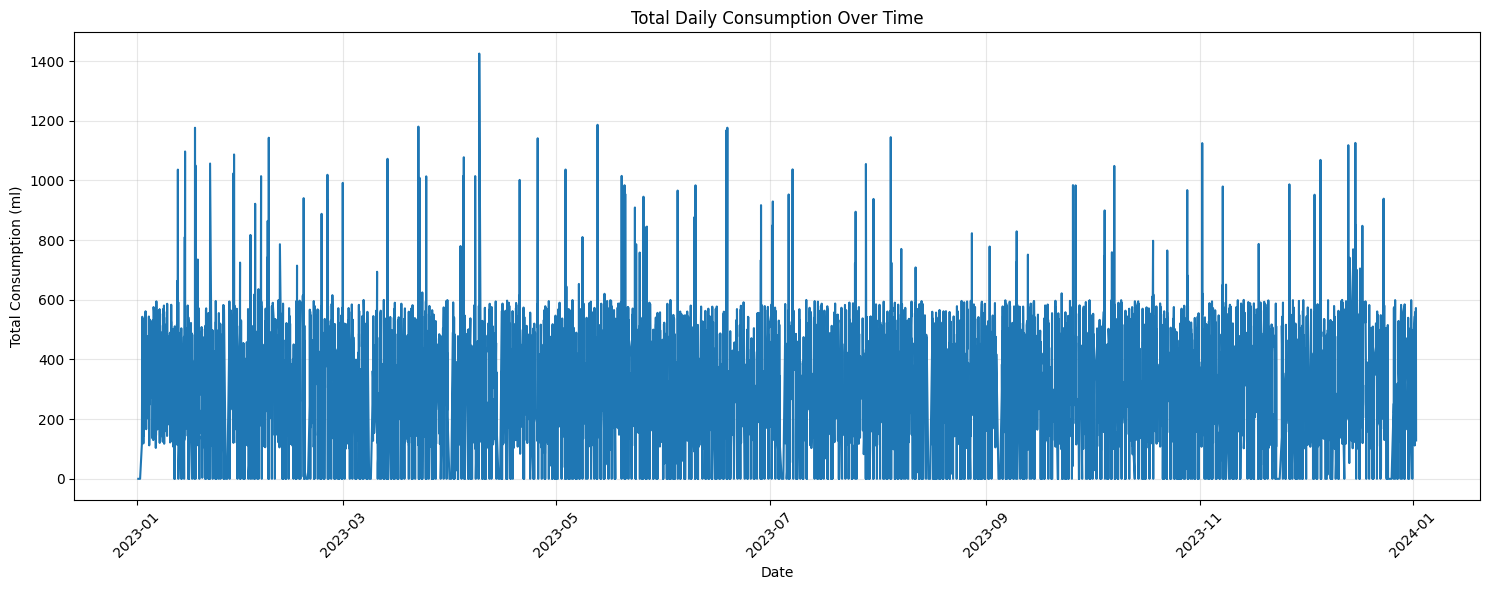

In [11]:

daily_consumption = df.groupby('Date Time Served')['Consumed (ml)'].sum()

plt.figure(figsize=(15, 6))
plt.plot(daily_consumption.index, daily_consumption.values)
plt.title('Total Daily Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Total Consumption (ml)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

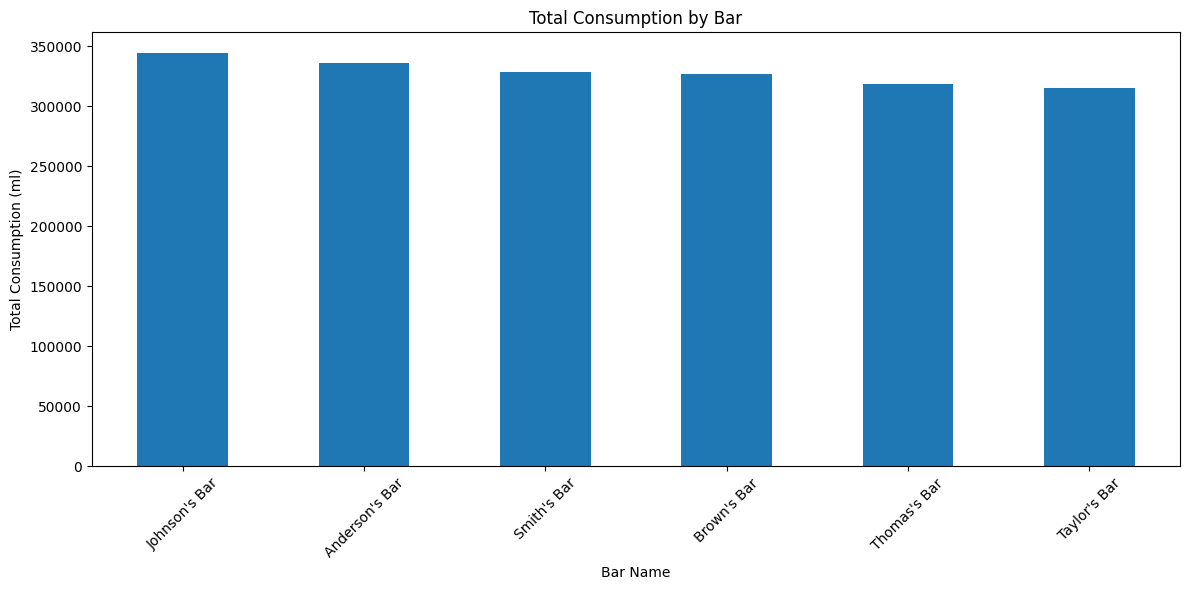

In [12]:
# Consumption by bar
plt.figure(figsize=(12, 6))
df.groupby('Bar Name')['Consumed (ml)'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Consumption by Bar')
plt.xlabel('Bar Name')
plt.ylabel('Total Consumption (ml)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


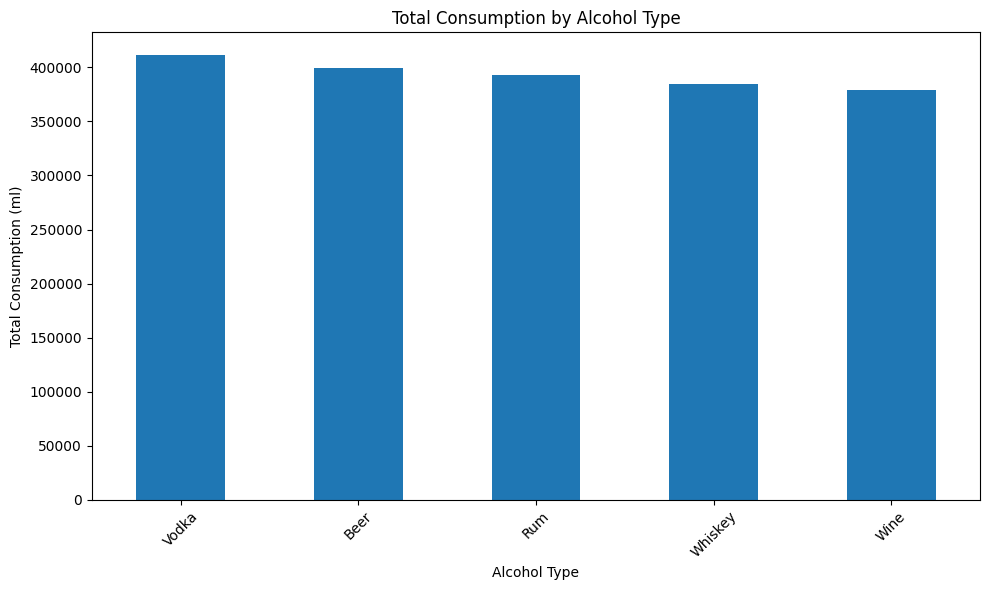

In [13]:
# Consumption by alcohol type
plt.figure(figsize=(10, 6))
df.groupby('Alcohol Type')['Consumed (ml)'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Consumption by Alcohol Type')
plt.xlabel('Alcohol Type')
plt.ylabel('Total Consumption (ml)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

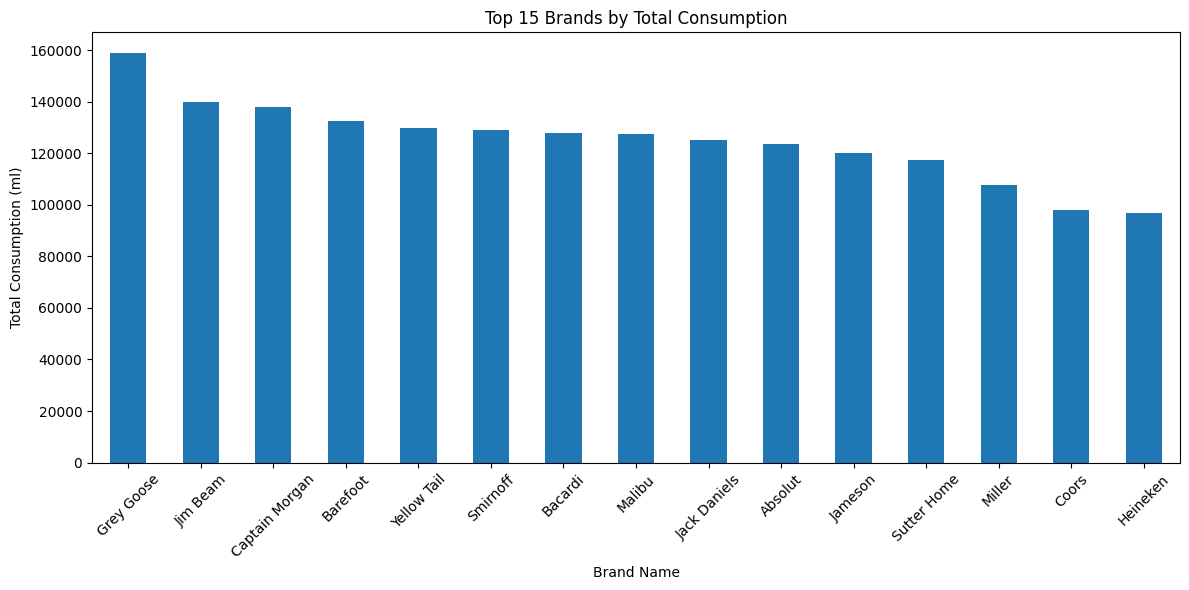

In [14]:
# Top brands consumption
plt.figure(figsize=(12, 6))
df.groupby('Brand Name')['Consumed (ml)'].sum().sort_values(ascending=False).head(15).plot(kind='bar')
plt.title('Top 15 Brands by Total Consumption')
plt.xlabel('Brand Name')
plt.ylabel('Total Consumption (ml)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

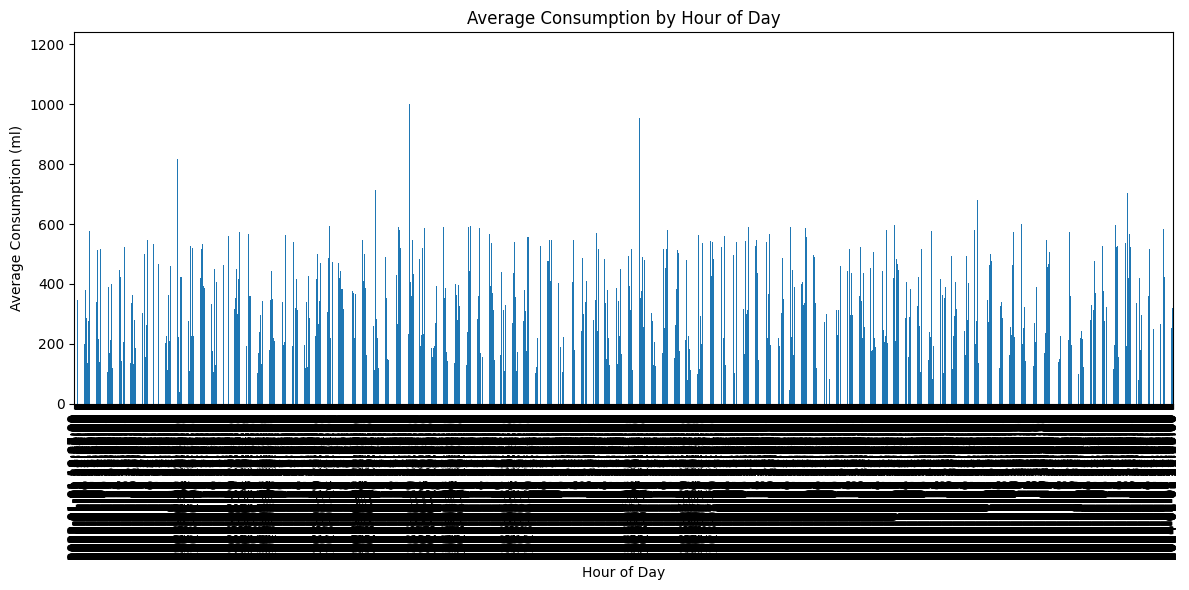

In [15]:
# Hourly patterns
plt.figure(figsize=(12, 6))
df.groupby('Date Time Served')['Consumed (ml)'].mean().plot(kind='bar')
plt.title('Average Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Consumption (ml)')
plt.tight_layout()
plt.show()

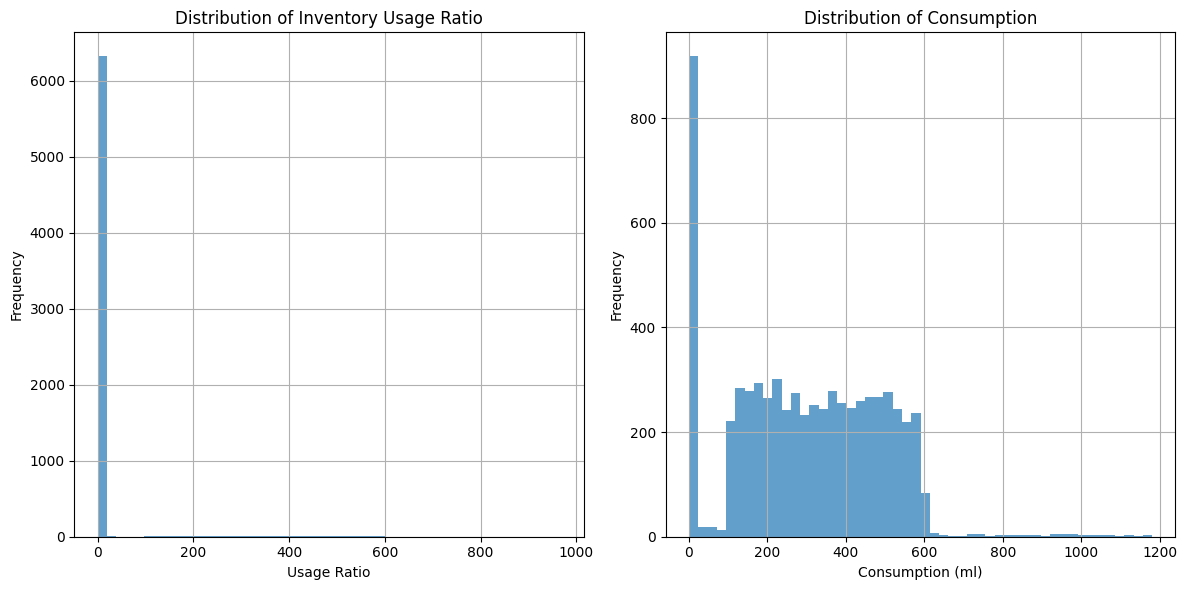

In [16]:
# Inventory analysis
df['Inventory_Usage_Ratio'] = df['Consumed (ml)'] / (df['Opening Balance (ml)'] + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df['Inventory_Usage_Ratio'].hist(bins=50, alpha=0.7)
plt.title('Distribution of Inventory Usage Ratio')
plt.xlabel('Usage Ratio')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df['Consumed (ml)'].hist(bins=50, alpha=0.7)
plt.title('Distribution of Consumption')
plt.xlabel('Consumption (ml)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


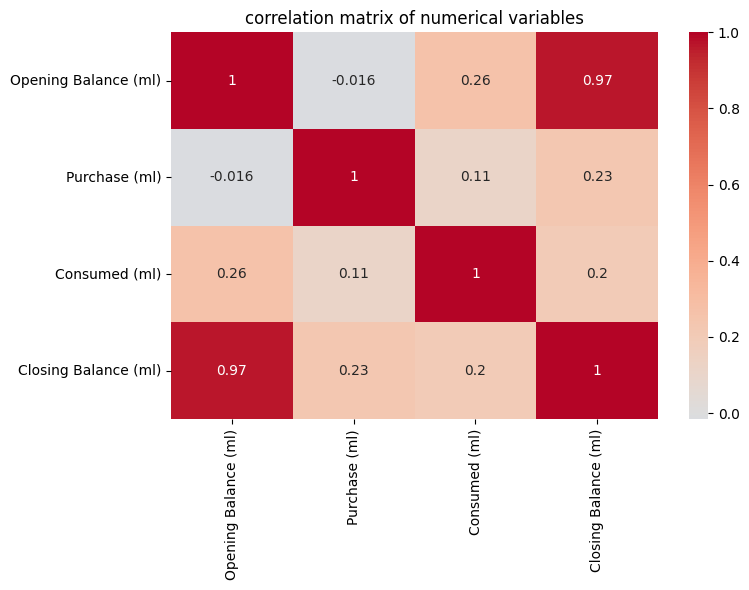

In [17]:
# Correlation
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center = 0)
plt.title('correlation matrix of numerical variables')
plt.tight_layout()
plt.show()

In [18]:
# Outlier detection using IQR
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

outliers_consumption = detect_outliers(df['Consumed (ml)'])
print(f"Outliers in consumption: {len(outliers_consumption)} ({len(outliers_consumption)/len(df)*100:.2f}%)")

Outliers in consumption: 44 (0.67%)


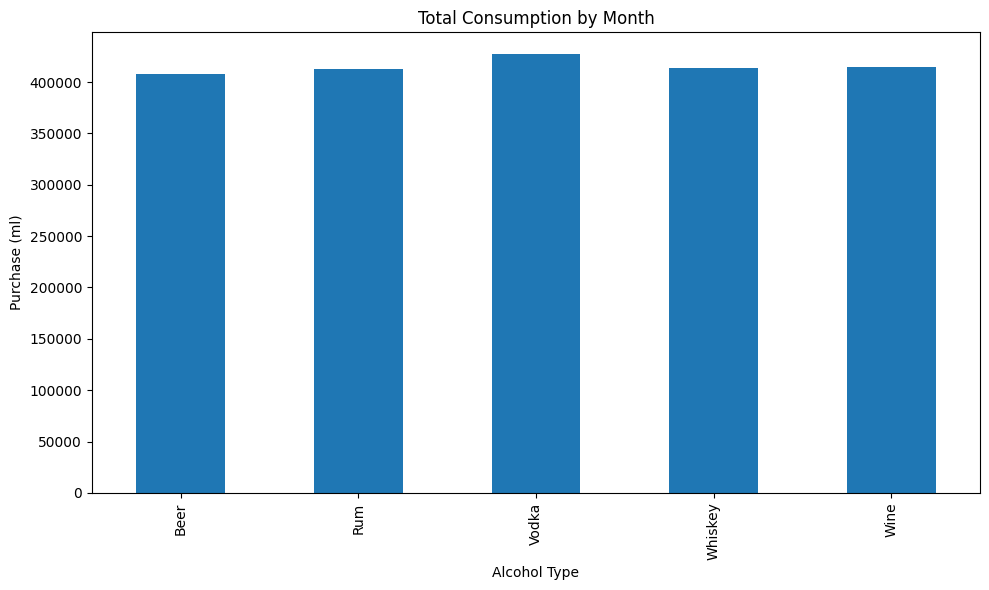

In [19]:
# Seasonal decomposition (simplified)
monthly_consumption = df.groupby('Alcohol Type')['Purchase (ml)'].sum()

plt.figure(figsize=(10, 6))
monthly_consumption.plot(kind='bar')
plt.title('Total Consumption by Month')
plt.xlabel('Alcohol Type')
plt.ylabel('Purchase (ml)')
plt.tight_layout()
plt.show()

In [20]:
# Key insights summary
print("=== KEY INSIGHTS SUMMARY ===")
print(f"1. Data covers {df['Date Time Served'].nunique()} days from {df['Date Time Served'].min()} to {df['Date Time Served'].max()}")
print(f"2. Total consumption: {df['Consumed (ml)'].sum():,.0f} ml")
print(f"3. Average daily consumption: {df['Consumed (ml)'].mean():.0f} ml")
print(f"4. Most popular alcohol type: {df.groupby('Alcohol Type')['Consumed (ml)'].sum().idxmax()}")
print(f"5. Busiest bar: {df.groupby('Bar Name')['Consumed (ml)'].sum().idxmax()}")
print(f"6. Data quality: {negative_consumption} negative consumption records found")


=== KEY INSIGHTS SUMMARY ===
1. Data covers 6497 days from 2023-01-01 10:07:00 to 2024-01-01 22:46:00
2. Total consumption: 1,968,682 ml
3. Average daily consumption: 299 ml
4. Most popular alcohol type: Vodka
5. Busiest bar: Johnson's Bar
6. Data quality: 0 negative consumption records found


In [21]:
# Recommendations for next steps
print("\n=== RECOMMENDATIONS FOR FEATURE ENGINEERING ===")
print("1. Handle negative values in consumption/purchase")
print("2. Create lag features for time series patterns")
print("3. Add seasonal features (day of week, month, holidays)")
print("4. Create rolling statistics for demand patterns")
print("5. Encode categorical variables (bars, alcohol types, brands)")
print("6. Create inventory-related features (stockout risk, turnover)")


=== RECOMMENDATIONS FOR FEATURE ENGINEERING ===
1. Handle negative values in consumption/purchase
2. Create lag features for time series patterns
3. Add seasonal features (day of week, month, holidays)
4. Create rolling statistics for demand patterns
5. Encode categorical variables (bars, alcohol types, brands)
6. Create inventory-related features (stockout risk, turnover)
